# Matrix-exponential neural flow

`MatrixExponential` is the simplest non-trivial *time-indexed neural flow*:

$$y = \exp(W\, t)\, x + h(t)\, b, \qquad \log\,|\det \partial y/\partial x| = t \cdot \mathrm{tr}(W).$$

Compared with FFJORD this is **closed-form** — no ODE solver, no Hutchinson
trace — but **linear in $x$**, so a single layer can only realise an affine
map. Stacking layers (with non-linear time gates between them) gives a
tractable, ODE-free alternative for the same family of problems FFJORD
handles.

Highlights of this notebook:

- The map is the identity at $t = 0$ because $\exp(0) = I$ and the default
  time gate satisfies $h(0) = 0$.
- The log-det is exact and analytic — verified against `slogdet(jacrev)`.
- Stacking realises a richer family while keeping all three properties above.

In [1]:
from __future__ import annotations

import equinox as eqx
import jax
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from flowjax.bijections import Chain
from flowjax.distributions import Normal, Transformed
from flowjax.train import fit_to_data

from gauss_flows import MatrixExponential, TimeTanh, pack_time_control

sns.set_theme(context="poster", style="whitegrid", palette="deep", font_scale=0.85)
plt.rcParams.update(
    {
        "figure.dpi": 110,
        "figure.constrained_layout.use": True,
        "axes.grid.which": "both",
        "grid.linewidth": 0.7,
        "grid.alpha": 0.5,
        "axes.titleweight": "semibold",
    }
)


def style_axes(ax, *, aspect=None):
    ax.minorticks_on()
    ax.grid(True, which="major", linewidth=0.8, alpha=0.6)
    ax.grid(True, which="minor", linewidth=0.4, alpha=0.3)
    if aspect is not None:
        ax.set_aspect(aspect)
    return ax


palette = sns.color_palette("deep")

/home/azureuser/localfiles/gauss_flows/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. A single layer pushing a unit circle

Take the unit circle in $\mathbb{R}^2$, push it through $\exp(W t)\cdot\, \cdot\, + h(t)\, b$
for $t \in [0, 1]$, and watch it morph from the identity at $t=0$ into a
rotated/scaled/translated ellipse at $t=1$.

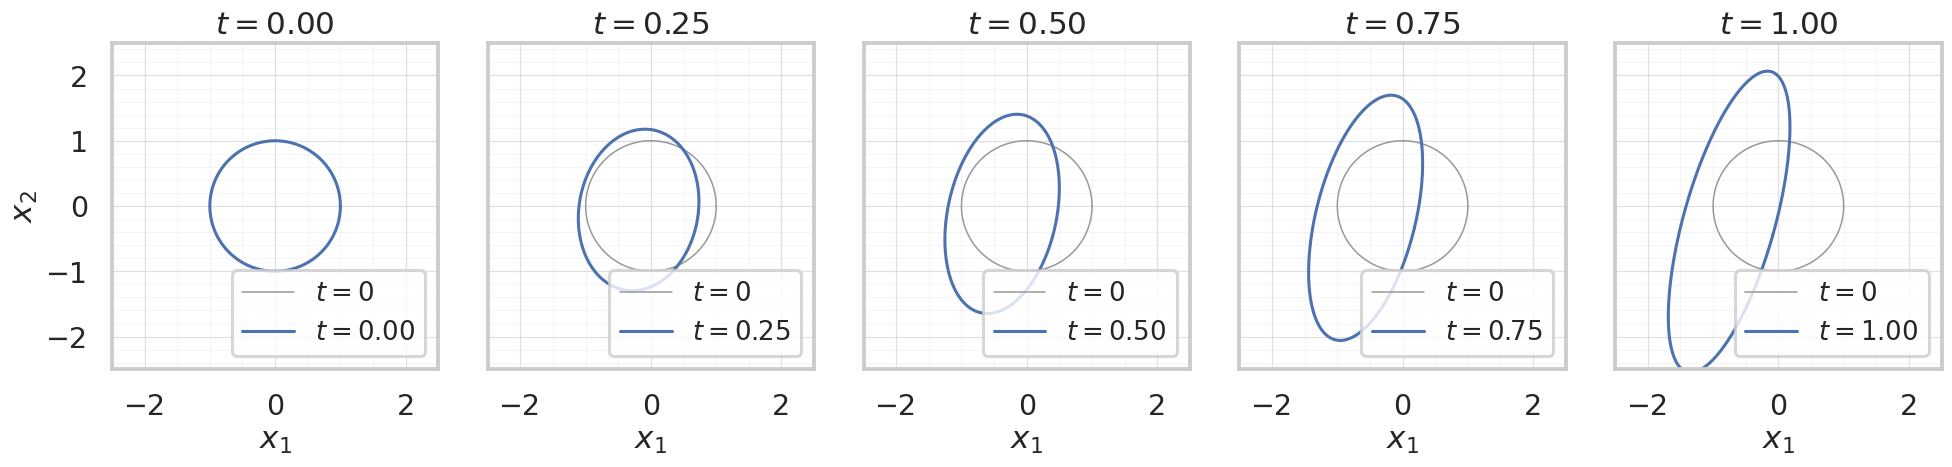

In [2]:
key = jr.key(0)
bij_key, fit_key, sample_key = jr.split(key, 3)

single = MatrixExponential(
    bij_key,
    shape=(2,),
    w_init_scale=0.6,  # large enough to make the warp visible
)

theta = jnp.linspace(0.0, 2 * jnp.pi, 200)
ring = jnp.stack([jnp.cos(theta), jnp.sin(theta)], axis=-1)

times = jnp.linspace(0.0, 1.0, 5)
fig, axes = plt.subplots(1, 5, figsize=(18, 4), sharex=True, sharey=True)
for ax, t in zip(axes, times, strict=True):
    cond = pack_time_control(float(t))
    pushed = jax.vmap(lambda p: single.transform_and_log_det(p, cond)[0])(ring)
    ax.plot(
        np.asarray(ring[:, 0]),
        np.asarray(ring[:, 1]),
        color="0.6",
        linewidth=1,
        label=r"$t=0$",
    )
    ax.plot(
        np.asarray(pushed[:, 0]),
        np.asarray(pushed[:, 1]),
        color=palette[0],
        linewidth=2,
        label=rf"$t={t:.2f}$",
    )
    ax.set_xlim(-2.5, 2.5)
    ax.set_ylim(-2.5, 2.5)
    ax.set_title(rf"$t = {float(t):.2f}$")
    ax.set_xlabel("$x_1$")
    ax.legend(loc="lower right", fontsize="small")
    style_axes(ax, aspect="equal")
axes[0].set_ylabel("$x_2$")
plt.show()

## 2. Closed-form log-det vs `slogdet(jacrev)`

The log-determinant has the analytic form $t \cdot \mathrm{tr}(W)$, regardless
of the time gate $h$ (the bias term shifts but doesn't scale). We verify this
matches autodiff on a non-trivial layer with a learned time gate.

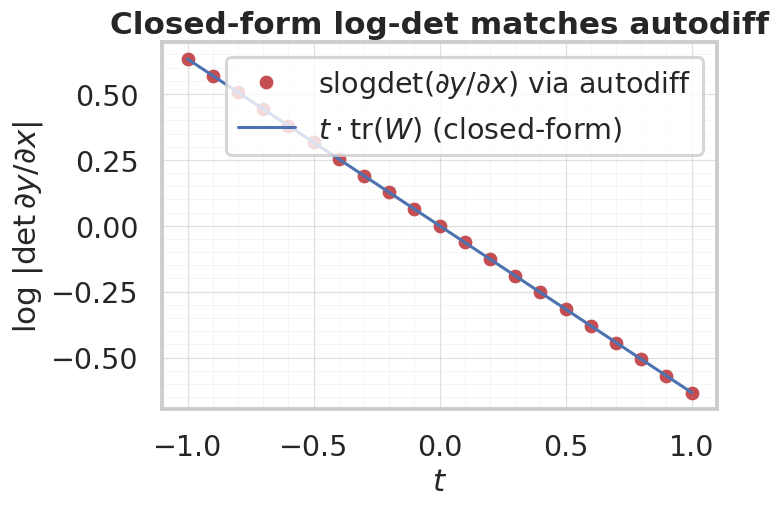

max |closed - autodiff| over 21 query times: 2.38e-07


In [3]:
gate_key, w_key = jr.split(jr.key(1), 2)
checked = MatrixExponential(
    w_key,
    shape=(4,),
    time_bias_net=TimeTanh(gate_key, embedding_dim=8),
    w_init_scale=0.2,
)


def forward(x, t):
    cond = pack_time_control(t)
    y, _ = checked.transform_and_log_det(x, cond)
    return y


x_eval = jr.normal(jr.key(2), (4,))
ts = jnp.linspace(-1.0, 1.0, 21)

closed = jax.vmap(lambda t: t * jnp.trace(checked.W))(ts)
ad = jax.vmap(
    lambda t: jnp.linalg.slogdet(jax.jacrev(forward, argnums=0)(x_eval, t))[1]
)(ts)

fig, ax = plt.subplots(figsize=(6.5, 4.5))
ax.plot(
    np.asarray(ts),
    np.asarray(ad),
    "o",
    color=palette[3],
    label=r"slogdet$(\partial y/\partial x)$ via autodiff",
    markersize=8,
)
ax.plot(
    np.asarray(ts),
    np.asarray(closed),
    "-",
    color=palette[0],
    label=r"$t \cdot \mathrm{tr}(W)$ (closed-form)",
    linewidth=2,
)
ax.set_xlabel("$t$")
ax.set_ylabel(r"$\log\,|\det \partial y/\partial x|$")
ax.set_title("Closed-form log-det matches autodiff")
ax.legend()
style_axes(ax)
plt.show()

max_gap = float(jnp.max(jnp.abs(closed - ad)))
print(f"max |closed - autodiff| over 21 query times: {max_gap:.2e}")

## 3. Fit an anisotropic Gaussian target

**Important caveat.** A chain of `MatrixExponential` layers is *still*
affine in $x$ at any fixed query time $t$ (the composition of affine maps is
affine). It is genuinely a more flexible *parameterisation* than a single
linear layer — each block has its own $W$, $b$, and time gate — but it can
only realise the family of affine push-forwards of the base Gaussian. Use
this when your target is well-modelled by a Gaussian with arbitrary
covariance and mean.

To model **multi-modal** or otherwise non-Gaussian densities, pair
`MatrixExponential` with a non-linear layer (`AffineCoupling`,
`DeepSigmoidCoupling`, `RQSplineCoupling`, …) — the matrix exponential then
acts as a learned, exactly-invertible "rotation + scale" between non-linear
blocks.

The target here is a strongly tilted, anisotropic 2D Gaussian. That is
exactly the family `MatrixExponential` was designed for, so we expect a
tight fit. We freeze the time query at $t=1$ throughout training so the
flow behaves as a deterministic composition.

In [4]:
target_key = jr.key(7)
n_samples = 2000
# Tilted anisotropic Gaussian: rotate a (3, 0.5) covariance by 30 degrees.
angle = jnp.pi / 6
R = jnp.array([[jnp.cos(angle), -jnp.sin(angle)], [jnp.sin(angle), jnp.cos(angle)]])
scale = jnp.array([2.0, 0.4])
mean = jnp.array([0.5, -0.5])
z = jr.normal(target_key, (n_samples, 2))
target = (z * scale) @ R.T + mean

In [5]:
n_layers = 4
layer_keys = jr.split(fit_key, n_layers)
layers = [
    MatrixExponential(
        k,
        shape=(2,),
        time_bias_net=TimeTanh(jr.fold_in(k, 99), embedding_dim=8),
        w_init_scale=0.3,
    )
    for k in layer_keys
]
chain = Chain(layers)
dist = Transformed(Normal(jnp.zeros(2)), chain)

# Pin the time query at t = 1 for every training example.
t_one = jnp.broadcast_to(pack_time_control(1.0), (n_samples, 1))

trained_dist, losses = fit_to_data(
    fit_key,
    dist,
    (target, t_one),
    learning_rate=5e-3,
    max_epochs=400,
    max_patience=40,
    batch_size=256,
    val_prop=0.1,
    show_progress=False,
)

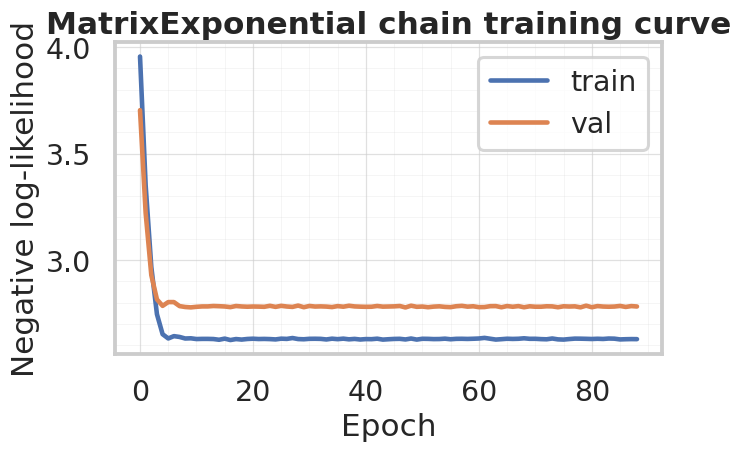

In [6]:
fig, ax = plt.subplots(figsize=(6, 4))
epochs = jnp.arange(len(losses["train"]))
ax.plot(epochs, losses["train"], label="train", color=palette[0])
ax.plot(epochs, losses["val"], label="val", color=palette[1])
ax.set_xlabel("Epoch")
ax.set_ylabel("Negative log-likelihood")
ax.set_title("MatrixExponential chain training curve")
ax.legend()
style_axes(ax)
plt.show()

### Density and samples

The fitted chain produces a closed-form log-density on a grid in
milliseconds (no ODE), and we sample by pushing base draws forward.

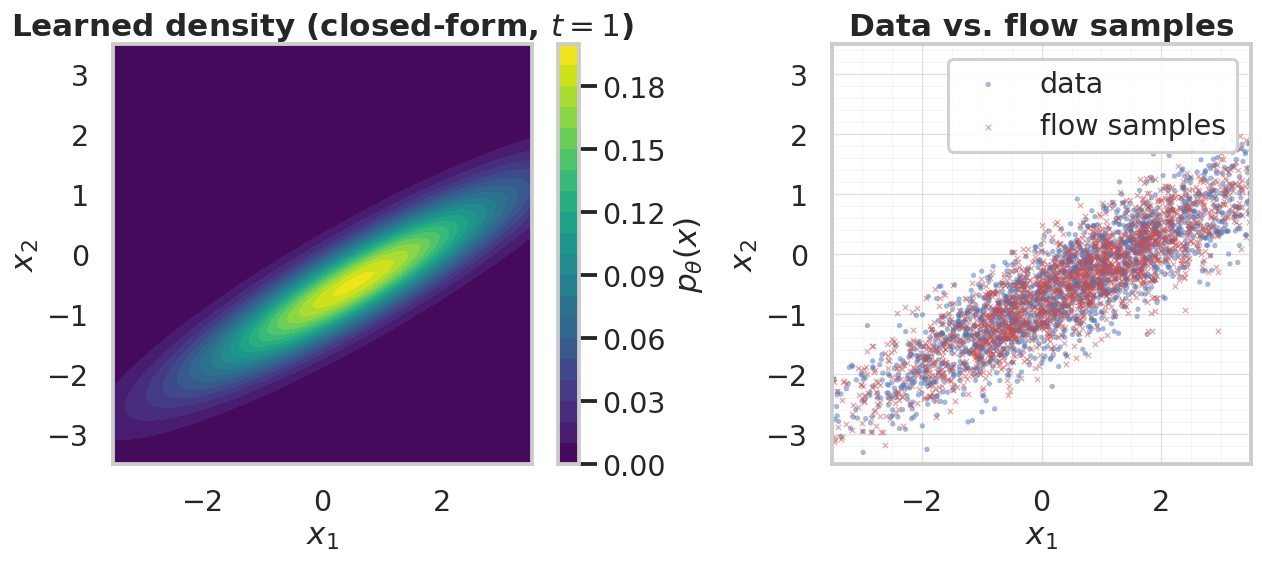

In [7]:
grid_n = 80
lim = 3.5
xs = jnp.linspace(-lim, lim, grid_n)
gx, gy = jnp.meshgrid(xs, xs)
grid_pts = jnp.stack([gx.ravel(), gy.ravel()], axis=-1)
grid_cond = jnp.broadcast_to(pack_time_control(1.0), (grid_pts.shape[0], 1))


@eqx.filter_jit
def grid_log_prob(pts, cond):
    return jax.vmap(trained_dist.log_prob)(pts, cond)


log_probs = grid_log_prob(grid_pts, grid_cond).reshape(grid_n, grid_n)
density = jnp.exp(log_probs)

flow_samples = trained_dist.sample(
    sample_key, (n_samples,), condition=pack_time_control(1.0)
)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ax_d, ax_s = axes
mesh = ax_d.contourf(
    np.asarray(gx), np.asarray(gy), np.asarray(density), levels=20, cmap="viridis"
)
ax_d.set_title("Learned density (closed-form, $t=1$)")
ax_d.set_xlabel("$x_1$")
ax_d.set_ylabel("$x_2$")
fig.colorbar(mesh, ax=ax_d, label="$p_\\theta(x)$")
style_axes(ax_d, aspect="equal")

ax_s.scatter(
    np.asarray(target[:, 0]),
    np.asarray(target[:, 1]),
    s=12,
    alpha=0.5,
    color=palette[0],
    label="data",
    edgecolors="none",
)
ax_s.scatter(
    np.asarray(flow_samples[:, 0]),
    np.asarray(flow_samples[:, 1]),
    s=12,
    alpha=0.5,
    color=palette[3],
    label="flow samples",
    marker="x",
    linewidths=0.8,
)
ax_s.set_xlim(-lim, lim)
ax_s.set_ylim(-lim, lim)
ax_s.set_title("Data vs. flow samples")
ax_s.set_xlabel("$x_1$")
ax_s.set_ylabel("$x_2$")
ax_s.legend(loc="upper right", framealpha=0.9)
style_axes(ax_s, aspect="equal")
plt.show()

## 4. The whole *neural flow*: distributions indexed by $t$

Because the bijection is parameterised by $t$, training at $t=1$ also gives
us — for free — a smooth one-parameter family of push-forwards

$$p_t(\cdot) = (\exp(W_L t) \circ \cdots \circ \exp(W_1 t))_{\#}\, \mathcal{N}(0, I),$$

interpolating between the base Gaussian at $t=0$ and the fitted target at
$t=1$. This is the "neural flow" perspective and the reason `MatrixExponential`
uses the packed-time conditioning contract: a single trained model encodes
the entire trajectory of distributions, and you can query any intermediate
$t$ without re-training.

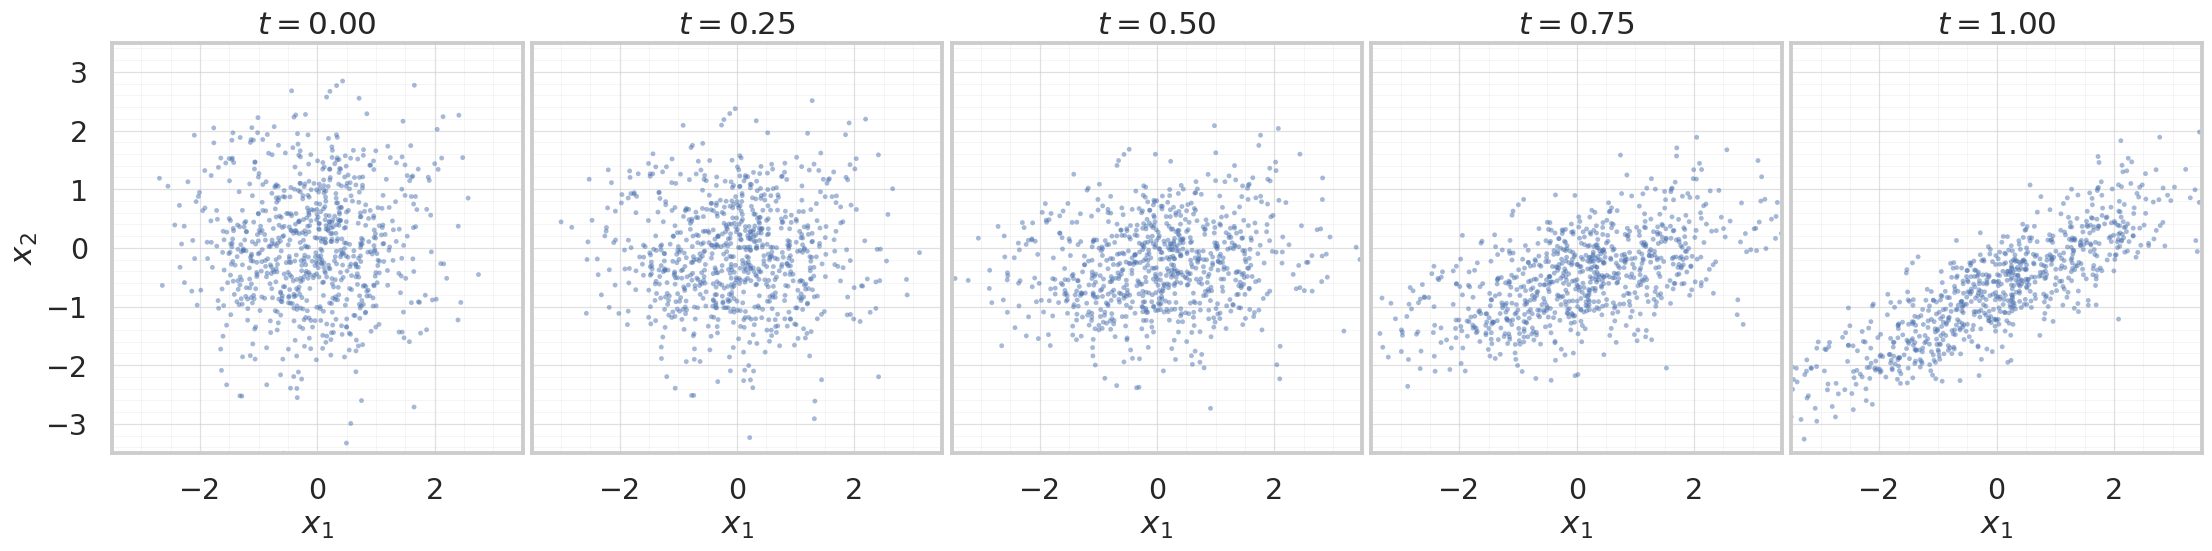

In [8]:
trained_chain = trained_dist.bijection
sweep_times = jnp.linspace(0.0, 1.0, 5)
sweep_n = 800
sweep_base = jr.normal(jr.fold_in(sample_key, 17), (sweep_n, 2))

fig, axes = plt.subplots(1, 5, figsize=(20, 5), sharex=True, sharey=True)
for ax, t in zip(axes, sweep_times, strict=True):
    cond_t = pack_time_control(float(t))
    pushed = jax.vmap(lambda z: trained_chain.transform_and_log_det(z, cond_t)[0])(
        sweep_base
    )
    ax.scatter(
        np.asarray(pushed[:, 0]),
        np.asarray(pushed[:, 1]),
        s=10,
        alpha=0.5,
        color=palette[0],
        edgecolors="none",
    )
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    ax.set_title(rf"$t = {float(t):.2f}$")
    ax.set_xlabel("$x_1$")
    style_axes(ax, aspect="equal")
axes[0].set_ylabel("$x_2$")
plt.show()

At $t=0$ the chain is the identity, so $p_0$ is the base Normal. As $t$ moves
from $0$ to $1$ the cloud smoothly tilts and stretches into the trained
anisotropic target. The matrix exponential gives this interpolation
*exactly*, with no ODE solve.

## 5. When to reach for which?

| property                              | `MatrixExponential` chain | `FFJORD`           |
|---------------------------------------|---------------------------|--------------------|
| exact log-det                         | yes ($t\cdot\mathrm{tr}(W)$ per layer) | no (Hutchinson during training) |
| closed-form forward / inverse         | yes (matrix exponential + linear solve) | no (ODE solve) |
| per-layer expressivity                | affine in $x$              | universal in $f_\theta(t,x)$ |
| training cost                         | dense matrix ops           | many ODE steps × Hutchinson probes |
| scaling to high $\dim$                | dominated by $O(\dim^3)$ matrix exp | dominated by ODE steps |

Use `MatrixExponential` chains when you want a fast, deterministic flow that
respects an explicit time index (e.g. a *time-indexed continuous-in-spirit*
model on tabular data, or as a cheap warm-start). Reach for FFJORD when the
data really wants a non-affine vector field per layer and you can afford the
ODE.